Dataset Link : https://drive.google.com/file/d/1rZfUzZ2bKlm5ltcrDALYsfoYMcU-yYrC/view?usp=sharing

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Upload the dataset
df = pd.read_csv("AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
df.head(36)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [ ]:
# Basics EDA ( Exploratory Data Analysis)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
# DateTime64(ns)
df["Month"]=pd.to_datetime(df["Month"]) # To fix the data type of Month column to its correct format

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
# Check for Null values
df.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

**we need to convert our datetime column to index ( This is a another requirement of our time series model )**

In [ ]:
df.set_index("Month", inplace=True)

In [ ]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


# Now we need to check do we have a **Stationary data or Non-Stationary data**

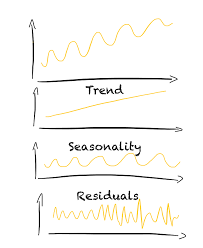

In [ ]:
# Non-stationary data will show both trend and seasionality
# Stationary data will not show trend and seasionality

# We need a Stationary data so if we have Non-stationary data we will convert it to Stationary data

<Axes: xlabel='Month'>

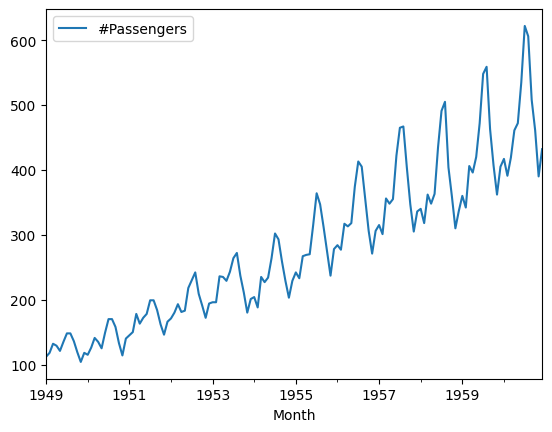

In [ ]:
# 1st Option by using Line plot
df.plot() # Checking trend and seasionality in the #Passengers COLUMN

**This graph shows that our data has both seasionality and trend**

Figure(640x480)


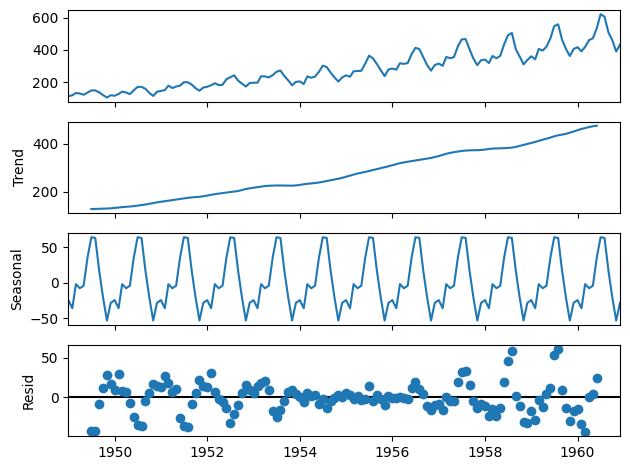

In [ ]:
# 2nd option is by using seasonal decompose
'''
seasonal_decompose(data) takes your time series data as input and decomposes it into three main components:

Trend: The overall direction or pattern in the data over a long period.
Seasonality: The repeating short-term cycle in the data (e.g., monthly or quarterly patterns).
Residual (Noise): The random variation or noise left after removing the trend and seasonality.
'''
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df)
print(decomposed.plot())

In [ ]:
# 3rd option is ADF Test
from statsmodels.tsa.stattools import adfuller # Augumented Dickey fuller test
result = adfuller(df)

In [ ]:
result  # we only need p_value which is present at index 1 of this result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
p_value = result[1]
p_value

np.float64(0.991880243437641)

In [ ]:
# Null hypothesis = Data is non - stationary
# Alternate hypothesis = Data is stationary

# If p value is less than 0.05 - Data is stationary
# If p value is more than 0.05 - Data is Non-Stationary

In [ ]:
if p_value <0.05:
  print("Data is stationary")
else:
  print("Data is Non-Stationary")

Data is Non-Stationary


**Stationarity: A stationary time series has constant mean and variance over time, which is crucial for many time series forecasting models.**

**As our data is not stationary we need to convert it to stationary form before model building**

To convert a non-stationary time series into a stationary one, we often use techniques that stabilize the mean and variance over time.

1) Remove seasionality

2) Remove trend

1st Step  to convert Non-Stationay data to Stationary data

**Logarithmic Transformation:** Applying a logarithm to the data is a common technique to stabilize the variance (reduce heteroscedasticity) and make the time series more stationary. This transformation compresses the scale of the data, especially for large values, and is particularly useful when dealing with exponential growth trends in time series data.

In [ ]:
first_log = np.log(df)
first_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


2nd Step to convert Non-Stationay data to Stationary data

**Rolling Mean (mean_log)**: This computes the moving average of the time series over a specified window (in this case, 12 time periods). It helps smooth out short-term fluctuations and highlights longer-term trends.

**Rolling Standard Deviation (std_log)**: Similarly, this computes the moving standard deviation over the same window, showing how much variation exists around the rolling mean.

In [ ]:
mean_log = first_log.rolling(window=12).mean()
mean_log.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


**Why NaN Values Appear:**

**Rolling Mean/Standard Deviation:** When you calculate a rolling mean or standard deviation over a window (e.g., 12 months), the first few values in the time series cannot be computed because there aren't enough preceding data points to fill the window. For instance, if you calculate a 12-month rolling mean, the first 11 months will have NaN values because there's insufficient data to compute the average.

**Example:** For the date 1949-01-01, the rolling window (12 months) does not have enough previous data points to calculate the rolling mean or standard deviation, hence it results in NaN.

3rd Step to convert Non-Stationay data to Stationary data

**Differencing**

By subtracting the rolling mean from the log-transformed data, you're removing the trend component from the data. This is a common technique in time series analysis to achieve stationarity.

In [ ]:
new_data = first_log - mean_log
new_data = new_data.dropna()  # we were having null values so we will drop them
new_data # New Stationary data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


**Again checking whether the data is staionary or not**

<Axes: xlabel='Month'>

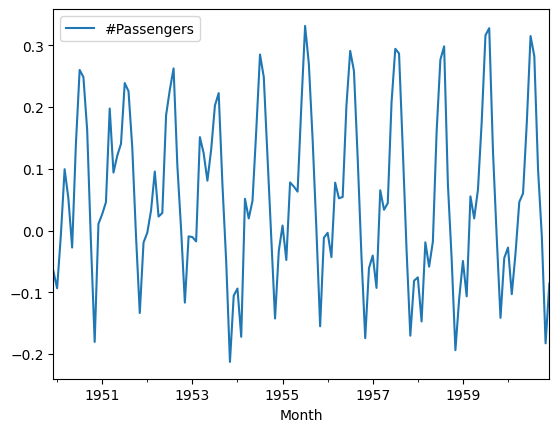

In [ ]:
# 1st Option by using Line plot
new_data.plot() # New Stationary data

<Axes: xlabel='Month'>

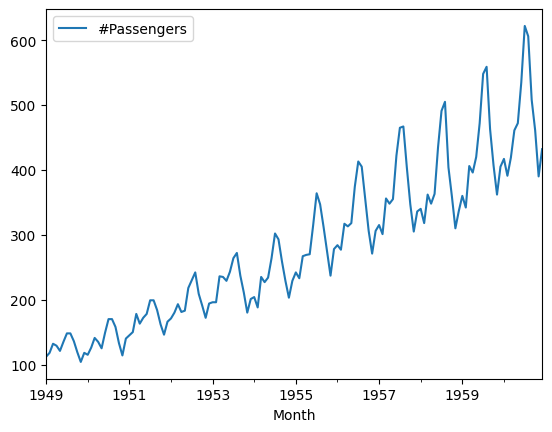

In [ ]:
df.plot() # Old Non-Stationary data

In [ ]:
# 3rd option is ADF Test
from statsmodels.tsa.stattools import adfuller # Augumented Dickey fuller test
result = adfuller(new_data)
p_value = result[1]
if p_value <0.05:
  print("Data is stationary")
else:
  print("Data is Non-Stationary")

Data is stationary


# Model building

In [ ]:
new_data

# Dec 1949 to Dec 1960 so total we have data of 133 months

# We need to divide this data for Training data and Testing data
# Training data - 120 months
# Testing data - 13 months

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
train = new_data[0:120]["#Passengers"]
test = new_data[120:]["#Passengers"]

In [ ]:
train

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1959-07-01,0.316430
1959-08-01,0.327838
1959-09-01,0.128057


In [ ]:
test

,#Passengers
Month,
1959-12-01,-0.044481
1960-01-01,-0.027530
1960-02-01,-0.103067
1960-03-01,-0.036530
1960-04-01,0.046332
1960-05-01,0.060186
1960-06-01,0.175033
1960-07-01,0.315151
1960-08-01,0.282363


# Arima model

In [ ]:
# # ARIMA -AutoRegressive Integrated Moving Average
# ARIMA - (p,d,q)

# p - order of lag   ,  p= ?
# d - degree of differencing  d=1
# q - order of moving average q= ?

'''
p: How many past values you want to use for prediction.
d: How many times you need to subtract past values to make the data steady.
q: How many past errors you want to use to improve your predictions.
'''

'\np: How many past values you want to use for prediction.\nd: How many times you need to subtract past values to make the data steady.\nq: How many past errors you want to use to improve your predictions.\n'

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# Training my arima model
arima_model = ARIMA( train , order = (12,1,13) )
arima_model = arima_model.fit()
# Make Prediction for 13 testing valus
new_data["Predicted_Passengers_values_column"] = arima_model.predict(start=len(train) , end=len(train)+len(test)-1)
# Now we will compare the Actual 13 testing values vs Predicted 13 values
new_data

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,#Passengers,Predicted_Passengers_values_column
Month,,
1949-12-01,-0.065494,NaN
1950-01-01,-0.093449,NaN
1950-02-01,-0.007566,NaN
1950-03-01,0.099416,NaN
1950-04-01,0.052142,NaN
...,...,...
1960-08-01,0.282363,0.315083
1960-09-01,0.098235,0.136839
1960-10-01,-0.009230,-0.008021


In [ ]:
# I need to start making predict for last 13 values

# Training data have values from index 0 to 119 = Total 120 values
# Testing data will have values from index 120 to 133 = Total 13 values

# start point of making prediction will be index = 120
# end point of making prediction will be 133

<Axes: xlabel='Month'>

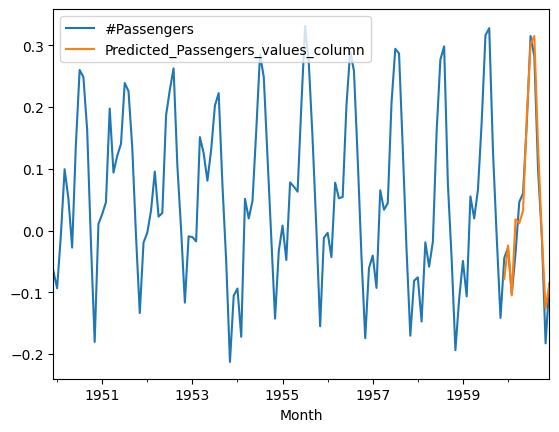

In [ ]:
new_data[["#Passengers", "Predicted_Passengers_values_column"]].plot()

# Now to find the optimal value of p,d,q we will use itertools

In [ ]:
import itertools
p=range(0,7)  # From 0 to 7 p values i will try
d=range(1,2)
q=range(0,7) # From 0 to 7 q values i will try
# I will create some combination of pdq by using different different value combination
pdq=list(itertools.product(p,d,q))
# I will use rmse to check with pdq values gives how much error between actual and predicted value
rmse=[]
# I will use a list to store which pdq i used to find that rmse score
order_list=[]

for i in pdq: # With different combination of pdq i will multiple models and i will check which model gives me least rmse
  arima_model = ARIMA( train , order = i)
  arima_model = arima_model.fit()
  pred = arima_model.predict(start=len(train) , end=len(train)+len(test)-1)
  from sklearn.metrics import *
  error = np.sqrt(mean_squared_error(test,pred))  # Find rmse
  order_list.append(i) # Add pqd combination of this model to list
  rmse.append(error) # Add error of this model to list

# Create a datframe that will lowest rmse and its pdq value
result = pd.DataFrame(index=order_list , data=rmse, columns=["RMSE"])
result.sort_values(by="RMSE", ascending=True)
result

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,RMSE
"(0, 1, 0)",0.228469
"(0, 1, 1)",0.252662
"(0, 1, 2)",0.140613
"(0, 1, 3)",0.140137
"(0, 1, 4)",0.136973
"(0, 1, 5)",0.139084
"(0, 1, 6)",0.141832
"(1, 1, 0)",0.255431
"(1, 1, 1)",0.240002
"(1, 1, 2)",0.137078


**SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) is an advanced time series forecasting model that extends the ARIMA model**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train , order=(6,1,6), seasonal_order=(6,1,6,12)) # This extra 12 is the window size
model = model.fit()
# Make Prediction for 13 testing valus
new_data["Predicted_Passengers_values_column_by_SARIMAX"] =model.predict(start=len(train) , end=len(train)+len(test)-1)
# Now we will compare the Actual 13 testing values vs Predicted 13 values
new_data

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,#Passengers,Predicted_Passengers_values_column,Predicted_Passengers_values_column_by_SARIMAX
Month,,,
1949-12-01,-0.065494,NaN,NaN
1950-01-01,-0.093449,NaN,NaN
1950-02-01,-0.007566,NaN,NaN
1950-03-01,0.099416,NaN,NaN
1950-04-01,0.052142,NaN,NaN
...,...,...,...
1960-08-01,0.282363,0.315083,0.313796
1960-09-01,0.098235,0.136839,0.124206
1960-10-01,-0.009230,-0.008021,-0.010617


<Axes: xlabel='Month'>

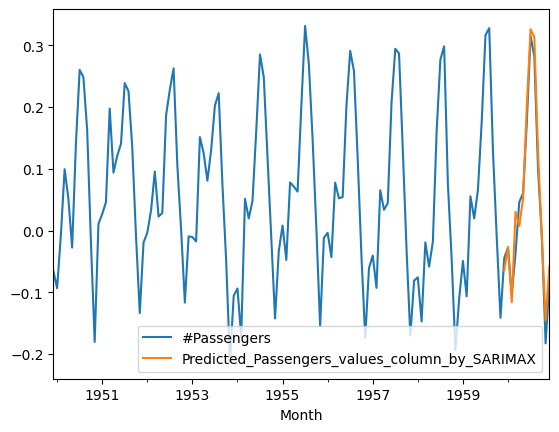

In [ ]:
new_data[["#Passengers", "Predicted_Passengers_values_column_by_SARIMAX"]].plot()

# We got out final model that is SARIMAX best for this data

Now we can use this model for forecast the value for some upcoming months

<Axes: xlabel='Month'>

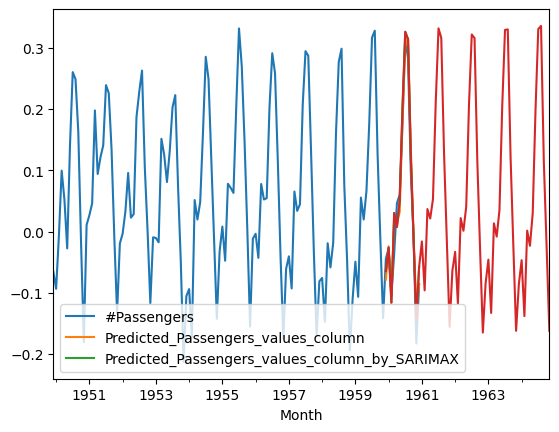

In [ ]:
# We were having data till december 1960 so we will forecast for next 5 years ( next 60 months) also
future = model.forecast(steps=60)  # red lines are the forecasted value for next 5 years
new_data.plot()
future.plot()

In [ ]:
future

# The process is reverse tranformation to get the actual passenger number

,predicted_mean
1959-12-01,-0.064581
1960-01-01,-0.026367
1960-02-01,-0.116171
1960-03-01,0.030268
1960-04-01,0.007455
1960-05-01,0.051503
1960-06-01,0.201682
1960-07-01,0.326032
1960-08-01,0.313796
1960-09-01,0.124206
